In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np
import seaborn as sns


In [6]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
df = df[df['v4'] >= 2000]
question_code = 'v33'
df

,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
345603,2391,2001.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,1,1,...,2,1,4,12,0,8,0.520,0,1,0.144
345604,2391,2002.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,2,...,10,0,4,12,0,8,0.550,0,1,0.153
345605,2391,2003.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,18,2,...,10,0,1,12,0,8,1.000,0,1,0.277
345606,2391,2004.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,4,99,23,...,10,0,4,12,0,8,1.200,0,1,0.333
345607,2391,2011.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,6,6,...,8,2,4,17,0,7,0.640,0,1,0.178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [7]:
dict_question_code_question = {
    "v1": "Studiennummer",
    "v2": "Befragtennummer",
    "v3": "Erhebungsmonat",
    "v4": "Erhebungsjahr",
    "V4a": "Erhebungsgebiet",
    "v5": "Wahlbeteiligung: Absicht",
    "v6": "Parteienwahl: Absicht",
    "v7": "Wahl: Rückerinnerung",
    "v8": "Skalometer: SPD",
    "v9": "Skalometer: CDU",
    "v10": "Skalometer: CSU",
    "v11": "Skalometer: FDP",
    "v12": "Skalometer: Grüne",
    "v13": "Skalometer: Republikaner/AfD",
    "v14": "Skalometer: PDS",
    "v15": "Skalometer: Regierung",
    "v16": "Skalometer: Opposition",
    "v17": "Skalometer: Grüne-Opposition",
    "v18": "Demokratiezufriedenheit",
    "v19": "Leute in führender Stellung",
    "v20": "Politikinteresse Befragter",
    "v21": "Stärke Politikinteresse",
    "v22": "Links-rechts-Kontinuum",
    "v23": "Linksorientierung",
    "v24": "Rechtsorientierung",
    "v25": "Beurteilung Wirtschaft in BRD",
    "v26": "Wirtschaftliche Lage in einem Jahr",
    "v27": "Eigene Wirtschaftslage",
    "v28": "Eigene Wirtschaftslage in einem Jahr",
    "v29": "Beurteilung Wiedervereinigung",
    "v30": "Beurteilung Asylrecht",
    "v31": "Ausländer in Deutschland",
    "v32": "Beurteilung Abtreibung",
    "v33": "BRD: Wichtige Probleme, 1.N.",
    "v34": "BRD: Wichtige Probleme, 2.N.",
    "v35": "Wer sichert Arbeitsplätze?",
    "v36": "Wer verbessert Wirtschaft West?",
    "v37": "Wer verbessert Wirtschaft Ost?",
    "v38": "Wer sorgt für Umweltschutz?",
    "v39": "Einstellung zu Kernkraft",
    "v40": "Wer sichert die Renten?",
    "v41": "Durch Kriminalität bedroht?",
    "v42": "EU-Mitgliedschaft",
    "v43": "Einheit versus Verantwortung",
    "v44": "Zustand der Gesellschaft",
    "v45": "Gesellschaft im Vergleich",
    "v46": "SPD Hinter Parteivorsitz",
    "v47": "CDU Hinter Parteivorsitz",
    "v48": "Fühlen Sie sich bedroht?",
    "v49": "Frieden sicherer geworden?",
    "v50": "Jahresrückblick",
    "v51": "Jahresausblick",
    "v52": "Konfession",
    "v53": "Kirchgang-Häufigkeit",
    "v54": "Geschlecht des Befragten",
    "v55": "Alter in Jahren",
    "v56": "Alter kategorisiert",
    "v57": "Familienstand",
    "v58": "Zusammenleben mit Partner",
    "v59": "Schulabschluss bis 09,87",
    "v60": "Schulabschluss ab 10,87",
    "v61": "Abgeschlossene Berufsausbildung",
    "v62": "Staatsexamen o.ä.",
    "v63": "Angestrebter Schulabschluss",
    "v64": "Berufstätigkeit",
    "v65": "Berufsgruppe",
    "v66": "Anzahl Personen im Haushalt",
    "v67": "Anzahl Personen ab 18",
    "v68": "Haushaltsvorstand",
    "v69": "HHV: Berufstätigkeit",
    "v70": "HHV: Berufsgruppe",
    "v71": "Eigener Arbeitsplatz gefährdet?",
    "v72": "Parteineigung",
    "v73": "Stärke der Parteineigung",
    "v74": "Gewerkschaftsmitglied",
    "v75": "Bundesland",
    "v76": "Ortsgröße",
    "v77": "Gemeindegröße",
    "v78": "Repräsentativgewicht",
    "v79": "Fragebogenversion",
    "v80": "Erhebung",
    "V81": "Gesamtgewicht"
}


In [8]:
partie_codes = {
    1  : 'CDU',
    2  : 'SPD',
    3  : 'FDP',
    4  : 'Gruene',
    8  : 'NPD',
    49 : 'AfD',
    97 : 'undecided'
}

In [9]:
keywords_fr = {
    1: "Retraite",
    5: "Inflation",
    10: "Impôts",
    13: "Économie",
    14: "Chômage",
    15: "Environnement",
    19: "Famille",
    20: "Système de santé",
    23: "Sécurité intérieure",
    27: "Affaires politiques",
    30: "Éducation",
    53: "Asile",
    54: "Immigration",
    55: "Crise de l'UE",
    56: "Dette publique",
    58: "Extrémisme de droite",
    66: "Autres",
    77: "Inégalités sociales",
    117: "Crise financière",
    134: "Coronavirus",
}

['v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v46', 'v47', 'v54', 'v55', 'v56', 'v57', 'v58', 'v59', 'v60', 'v61', 'v62', 'v63', 'v64', 'v65', 'v66', 'v67', 'v68', 'v69', 'v70', 'v78', 'v79', 'v80', 'v81']


<Axes: >

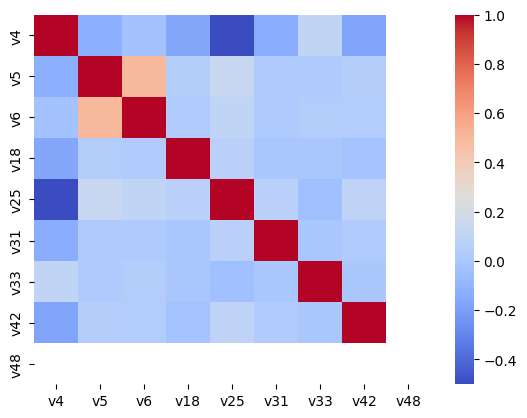

In [ ]:
exclude = [f'v{i}' for i in list(range(8,18)) + list(range(46,48)) + list(range(54,71)) + list(range(78,82))]
print(exclude)
df_reduced = df[[column for column in df.columns if column not in ['Version','doi'] + exclude]]
df_reduced = df[[column for column in df.columns if column in ['v4','v5','v6','v18','v25','v31','v33','v42','v48']]]

corr_matrix = df_reduced.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

           v4  v5  v6  v18  v25  v31  v33  v42  v48
345603   2000   1   1    2    4    0   27    2    0
345604   2000   1   2    2    3    0   14    3    0
345605   2000   1  18    2    3    0   27    2    0
345606   2000   4  99    2    9    0   14    3    0
345607   2000   1   6    3    3    0   14    2    0
...       ...  ..  ..  ...  ...  ...  ...  ...  ...
1046814  2022   1   4    0    3    0  999    1    0
1046815  2022   1   4    0    2    0   75    1    0
1046816  2022   1  38    0    3    0  110    3    0
1046817  2022   4  99    0    4    0   75    3    0
1046818  2022   1   1    0    3    0  110    1    0

[701216 rows x 9 columns]


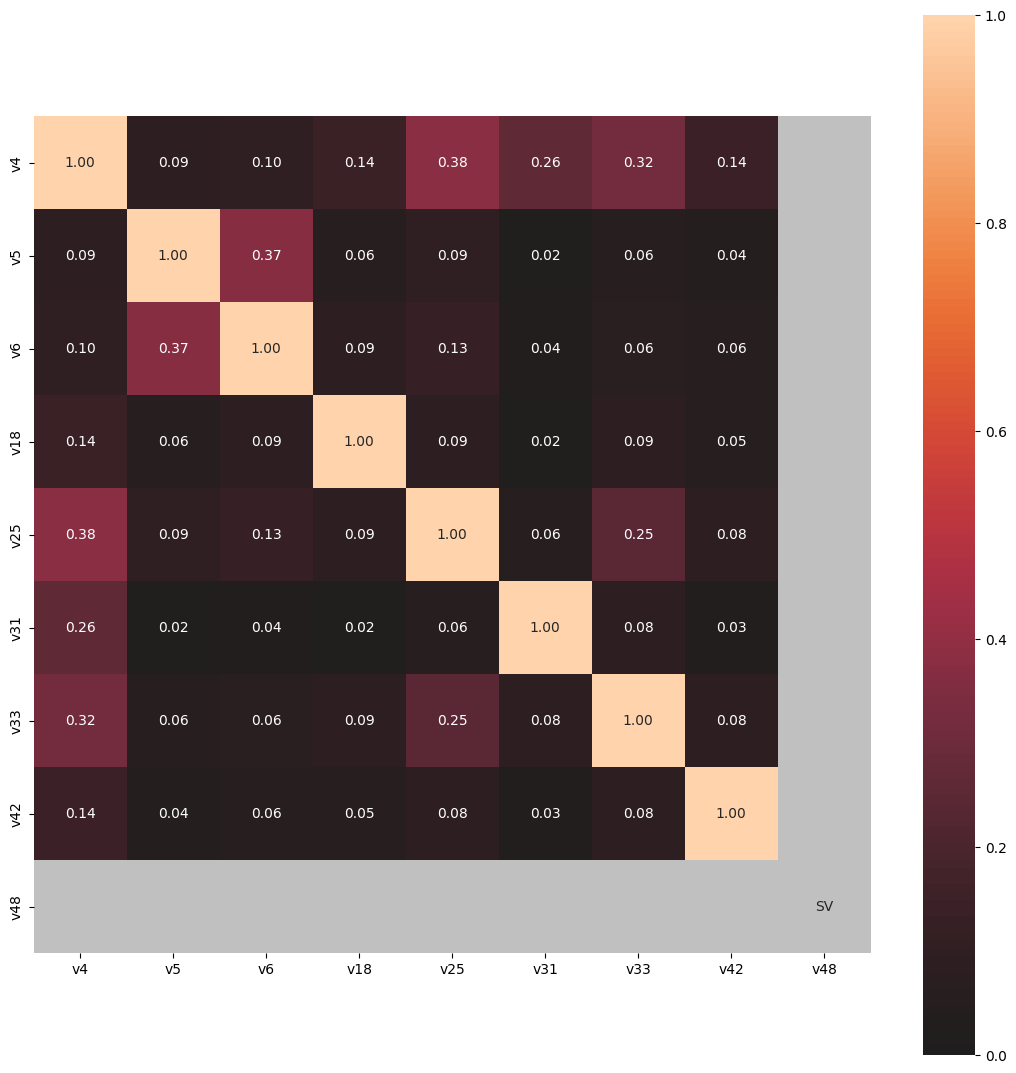

{'corr':            v4        v5        v6       v18       v25       v31       v33  \
 v4   1.000000  0.087080  0.097388  0.136650  0.376921  0.259359  0.320235   
 v5   0.087080  1.000000  0.374677  0.061891  0.094068  0.020322  0.062378   
 v6   0.097388  0.374677  1.000000  0.089972  0.128074  0.036997  0.062646   
 v18  0.136650  0.061891  0.089972  1.000000  0.093008  0.017644  0.086998   
 v25  0.376921  0.094068  0.128074  0.093008  1.000000  0.056043  0.249754   
 v31  0.259359  0.020322  0.036997  0.017644  0.056043  1.000000  0.082957   
 v33  0.320235  0.062378  0.062646  0.086998  0.249754  0.082957  1.000000   
 v42  0.142246  0.042638  0.062027  0.050395  0.084082  0.030603  0.082132   
 v48  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 
           v42  v48  
 v4   0.142246  0.0  
 v5   0.042638  0.0  
 v6   0.062027  0.0  
 v18  0.050395  0.0  
 v25  0.084082  0.0  
 v31  0.030603  0.0  
 v33  0.082132  0.0  
 v42  1.000000  0.0  
 v48  0.0000

In [11]:
print(df_reduced)
from dython.nominal import associations
associations(df_reduced,nominal_columns='all')

In [12]:
import scipy.stats as stats 
stats.fisher_exact(df_reduced[['v5','v4']].head(1000))

SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))

# PCA?

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale data before applying PCA
scaling=StandardScaler()
 
pca = PCA()
pca.fit(df_reduced)#
pca.explained_variance_ratio_


array([9.55815490e-01, 4.29900911e-02, 1.04908538e-03, 4.13082761e-05,
       3.62276007e-05, 3.02126251e-05, 2.70553311e-05, 1.05302024e-05,
       0.00000000e+00])

In [14]:
# Extract explained variance, explained variance ratio, and cumulative variance
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Create DataFrame
summary_table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance": explained_variance,
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance": cumulative_variance
})

summary_table

,Principal Component,Explained Variance,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,37207.492819,0.955815,0.955815
1,PC2,1673.496112,0.042990,0.998806
2,PC3,40.838255,0.001049,0.999855
3,PC4,1.608027,0.000041,0.999896
4,PC5,1.410249,0.000036,0.999932
5,PC6,1.176102,0.000030,0.999962
6,PC7,1.053196,0.000027,0.999989
7,PC8,0.409914,0.000011,1.000000
8,PC9,0.000000,0.000000,1.000000


In [15]:
import prince
df_reduced = df_reduced[[column for column in df_reduced.columns if column not in ['v1','v2','v3','v4a','v80','V81']]]
df_reduced

,v4,v5,v6,v18,v25,v31,v33,v42,v48
345603,2000,1,1,2,4,0,27,2,0
345604,2000,1,2,2,3,0,14,3,0
345605,2000,1,18,2,3,0,27,2,0
345606,2000,4,99,2,9,0,14,3,0
345607,2000,1,6,3,3,0,14,2,0
...,...,...,...,...,...,...,...,...,...
1046814,2022,1,4,0,3,0,999,1,0
1046815,2022,1,4,0,2,0,75,1,0
1046816,2022,1,38,0,3,0,110,3,0
1046817,2022,4,99,0,4,0,75,3,0


In [39]:
famd = prince.MCA(
    n_components=80,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
)
famd = famd.fit(df_reduced.head(int(1e5)))

In [22]:
famd

MCA(n_components=80, n_iter=3, random_state=42)

In [32]:
famd.plot(
    df_reduced.head(1000),
    x_component=0,
    y_component=1,
    show_column_markers=True,
    show_row_markers=True,
    show_column_labels=False,
    show_row_labels=False
)


alt.LayerChart(...)

In [40]:
famd.eigenvalues_summary.head(20)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.232,2.27%,2.27%
1,0.210,2.05%,4.33%
2,0.156,1.52%,5.85%
3,0.153,1.49%,7.34%
4,0.150,1.47%,8.81%
5,0.138,1.35%,10.16%
6,0.136,1.33%,11.49%
7,0.126,1.24%,12.73%
8,0.125,1.23%,13.95%


In [ ]:
print(famd.eigenvalues_summary.head(5).to_latex(escape=True))

\begin{tabular}{llll}
\toprule
 & eigenvalue & \% of variance & \% of variance (cumulative) \\
component &  &  &  \\
\midrule
\textbf{0} & 0.232 & 2.27\% & 2.27\% \\
\textbf{1} & 0.210 & 2.05\% & 4.33\% \\
\textbf{2} & 0.156 & 1.52\% & 5.85\% \\
\textbf{3} & 0.153 & 1.49\% & 7.34\% \\
\textbf{4} & 0.150 & 1.47\% & 8.81\% \\
\bottomrule
\end{tabular}



In [ ]:
chart = pca.plot(
     dataset)
chart

AttributeError: 'PCA' object has no attribute 'plot'